In [201]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv("IMDB_Movies_Dataset.csv")


In [203]:
print(df)

      Unnamed: 0                                       Title  Average Rating  \
0              0                    The Shawshank Redemption             9.3   
1              1  Attack on Titan the Movie: The Last Attack             9.3   
2              2                               The Godfather             9.2   
3              3                              Hababam Sinifi             9.2   
4              4         Ramayana: The Legend of Prince Rama             9.2   
...          ...                                         ...             ...   
4984         495                                La comunidad             7.2   
4985         496                           The House of Fear             7.2   
4986         497                              Kurôzu zero II             7.2   
4987         498                               La cage dorée             7.2   
4988         499                                     Chingoo             7.2   

                                Directo

In [205]:
df.describe()

,Unnamed: 0,Average Rating,Metascore
count,4989.000000,4989.000000,3055.000000
mean,248.951493,7.632892,74.684452
std,144.036753,0.365243,12.298911
min,0.000000,7.200000,25.000000
25%,124.000000,7.300000,67.000000
50%,249.000000,7.600000,76.000000
75%,374.000000,7.800000,84.000000
max,499.000000,9.300000,100.000000


In [207]:
df.isnull()


,Unnamed: 0,Title,Average Rating,Director,Writer,Metascore,Cast,Release Date,Country of Origin,Languages,Budget,Worldwide Gross,Runtime
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,True,True,False
4,False,False,False,False,False,True,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4984,False,False,False,False,False,True,False,False,False,False,False,False,False
4985,False,False,False,False,False,True,False,False,False,False,True,True,False
4986,False,False,False,False,False,True,False,False,False,False,True,False,False
4987,False,False,False,False,False,True,False,False,False,False,False,False,False


In [209]:
df['Budget'] = df['Budget'].fillna('UNKNOWN')
df['Worldwide Gross'] = df['Worldwide Gross'].fillna('UNKNOWN')

In [211]:
df.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

In [215]:
df.drop_duplicates(inplace=True)


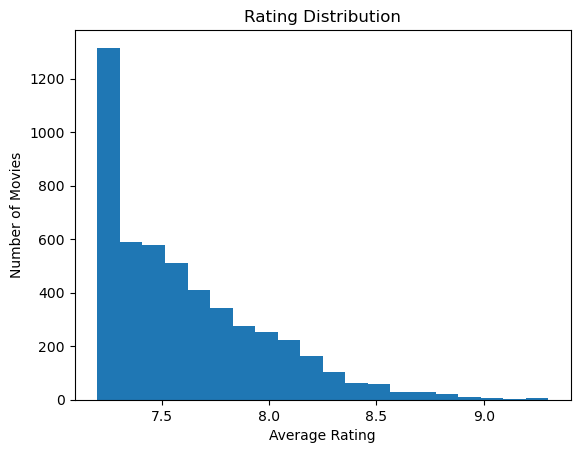

In [156]:
plt.hist(df['Average Rating'], bins=20)
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
plt.title('Rating Distribution')
plt.show()

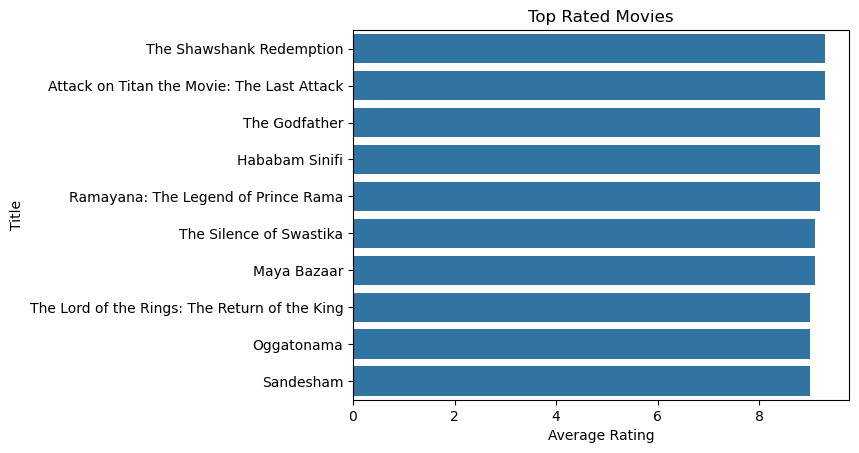

In [221]:
top_movies = df.sort_values('Average Rating', ascending=False).head(10)
sns.barplot(x=top_movies['Average Rating'],y=top_movies['Title'])
plt.title('Top Rated Movies')
plt.show()


In [217]:
df['Popularity Score'] = df['Average Rating'] * df['Metascore']


In [219]:
df['Content'] = (
    df['Director'] + ' ' +
    df['Writer'] + ' ' +
    df['Cast'] + ' ' +
    df['Languages']
)


In [241]:
import re

def money_to_numeric(value):
    if pd.isna(value):
        return np.nan
    value = str(value)
    # Remove $ sign, commas, and any text in parentheses
    value = re.sub(r'[\$,]', '', value)         # Remove $ and commas
    value = re.sub(r'\(.*?\)', '', value)      # Remove text in parentheses
    value = value.strip()
    if value == '':
        return np.nan
    try:
        return float(value)
    except:
        return np.nan

# Apply to your columns
df['Budget_numeric (in $)'] = df['Budget'].apply(money_to_numeric)
df['Worldwide_Gross_numeric (in $)'] = df['Worldwide Gross'].apply(money_to_numeric)


In [243]:
import re
def Runtime_to_minutes(Runtime):
    if pd.isna(Runtime):
        return np.nan
    Runtime = str(Runtime).lower().strip()
    
    hours = re.search(r'(\d+)\s*h', Runtime)
    minutes = re.search(r'(\d+)\s*m', Runtime)
    
    total_minutes = 0
    if hours:
        total_minutes += int(hours.group(1)) * 60
    if minutes:
        total_minutes += int(minutes.group(1))
    
    # If runtime is just a number, e.g., "95"
    if total_minutes == 0:
        try:
            total_minutes = int(re.search(r'(\d+)', Runtime).group(1))
        except:
            return np.nan
    
    return total_minutes

# Apply to your Runtime column
df['Runtime_minutes'] = df['Runtime'].apply(Runtime_to_minutes)


In [233]:
df

,Title,Average Rating,Director,Writer,Metascore,Cast,Release Date,Country of Origin,Languages,Budget,Worldwide Gross,Runtime,Popularity Score,Content,Budget_numeric (in $),Worldwide_Gross_numeric (in $),Runtime_minutes
0,The Shawshank Redemption,9.3,Frank Darabont,"Stephen King, Frank Darabont",82.0,"Tim Robbins, Morgan Freeman, Bob Gunton, Willi...","October 14, 1994 (India)",United States,English,"$25,000,000 (estimated)","$29,332,133",2 hours 22 minutes,762.6,"Frank Darabont Stephen King, Frank Darabont Ti...",25000000.0,29332133.0,142
1,Attack on Titan the Movie: The Last Attack,9.3,Yûichirô Hayashi,"Natsuki Hanae, Yoshimasa Hosoya, Marina Inoue",NaN,"Natsuki Hanae, Yoshimasa Hosoya, Marina Inoue,...","November 8, 2024 (Japan)",Japan,Japanese,UNKNOWN,"$3,513,659",2 hours 25 minutes,NaN,"Yûichirô Hayashi Natsuki Hanae, Yoshimasa Hoso...",NaN,3513659.0,145
2,The Godfather,9.2,Francis Ford Coppola,"Mario Puzo, Francis Ford Coppola",100.0,"Marlon Brando, Al Pacino, James Caan, Diane Ke...",1978 (India),United States,"English, Italian, Latin","$6,000,000 (estimated)","$250,342,198",2 hours 55 minutes,920.0,"Francis Ford Coppola Mario Puzo, Francis Ford ...",6000000.0,250342198.0,175
3,Hababam Sinifi,9.2,Ertem Egilmez,"Umur Bugay, Rifat Ilgaz",NaN,"Münir Özkul, Tarik Akan, Halit Akçatepe, Kemal...","April 1, 1975 (Turkey)",Turkey,Turkish,UNKNOWN,UNKNOWN,1 hour 25 minutes,NaN,"Ertem Egilmez Umur Bugay, Rifat Ilgaz Münir Öz...",NaN,NaN,85
4,Ramayana: The Legend of Prince Rama,9.2,"Ram Mohan, Yûgô Sakô, Koichi Saski","Rani Burra, Ram Mohan, Yûgô Sakô",NaN,"Arun Govil, Nikhil Kapoor, Edie Mirman, Rael P...","September 25, 2001 (India)","India, Japan",English,UNKNOWN,UNKNOWN,2 hours 15 minutes,NaN,"Ram Mohan, Yûgô Sakô, Koichi Saski Rani Burra,...",NaN,NaN,135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4984,La comunidad,7.2,Álex de la Iglesia,"Jorge Guerricaechevarría, Álex de la Iglesia",NaN,"Carmen Maura, Eduardo Antuña, María Asquerino,...","September 29, 2000 (Spain)",Spain,Spanish,"€4,000,000 (estimated)","$290,754",1 hour 50 minutes,NaN,"Álex de la Iglesia Jorge Guerricaechevarría, Á...",NaN,290754.0,110
4985,The House of Fear,7.2,Roy William Neill,"Roy Chanslor, Arthur Conan Doyle",NaN,"Basil Rathbone, Nigel Bruce, Aubrey Mather, De...","March 16, 1945 (United States)",United States,English,UNKNOWN,UNKNOWN,1 hour 9 minutes,NaN,"Roy William Neill Roy Chanslor, Arthur Conan D...",NaN,NaN,69
4986,Kurôzu zero II,7.2,Takashi Miike,"Hiroshi Takahashi, Shôgo Mutô",NaN,"Shun Oguri, Kyôsuke Yabe, Meisa Kuroki, Kenta ...","April 11, 2009 (Japan)",Japan,Japanese,UNKNOWN,"$29,893,636",2 hours 13 minutes,NaN,"Takashi Miike Hiroshi Takahashi, Shôgo Mutô Sh...",NaN,29893636.0,133
4987,La cage dorée,7.2,Ruben Alves,"Ruben Alves, Luc-Olivier Veuve, Jean-André Yerlès",NaN,"Rita Blanco, Joaquim de Almeida, Roland Giraud...","April 24, 2013 (France)",France,"French, Portuguese, English","€7,000,000 (estimated)","$17,871,370",1 hour 30 minutes,NaN,"Ruben Alves Ruben Alves, Luc-Olivier Veuve, Je...",NaN,17871370.0,90


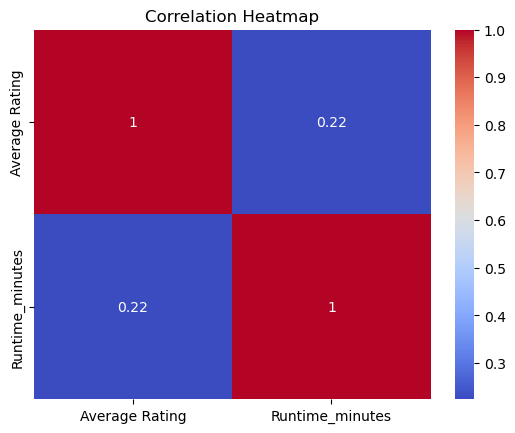

In [245]:
sns.heatmap(df[['Average Rating','Runtime_minutes']].corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [258]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

# Fill missing values for text columns
text_cols = ['Director', 'Writer', 'Cast', 'Languages']
for col in text_cols:
    df[col] = df[col].fillna('UNKNOWN')

# TF-IDF vectorization
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['Content'])

# Cosine similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)


In [251]:
def recommend_based_on_recent_watches(recent_movies, top_n=5):
    recommended_indices = set()
    
    for movie in recent_movies:
        if movie in df['Title'].values:
            idx = df[df['Title'] == movie].index[0]
            sim_scores = list(enumerate(cosine_sim[idx]))
            sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
            
            # Pick top 5 similar movies (excluding the movie itself)
            similar_movies = [i[0] for i in sim_scores[1:top_n+1]]
            recommended_indices.update(similar_movies)
    
    recommended_df = df.iloc[list(recommended_indices)]
    # Sort by Average Rating or other metric
    recommended_df = recommended_df.sort_values('Average Rating', ascending=False).head(top_n)
    return recommended_df[['Title', 'Average Rating', 'Runtime', 'Languages']]


In [254]:
recent_watched = input("Enter 1–3 movies you recently watched, separated by commas:\n")
recent_watched_list = [x.strip() for x in recent_watched.split(',')]


Enter 1–3 movies you recently watched, separated by commas:
 The Shawshank Redemption


In [256]:
recommended_movies = recommend_based_on_recent_watches(recent_watched_list, top_n=5)

if recommended_movies.empty:
    print("No recommendations found based on your recent watches 😢")
else:
    print("\nTop 5 movie recommendations for you:")
    for idx, row in recommended_movies.iterrows():
        print(f"{row['Title']} | Rating: {row['Average Rating']} | Runtime: {row['Runtime']} | Language: {row['Languages']}")



Top 5 movie recommendations for you:
The Green Mile | Rating: 8.6 | Runtime: 3 hours 9 minutes | Language: English, French
Dead Man Walking | Rating: 7.5 | Runtime: 2 hours 2 minutes | Language: English
The Hunt for Red October | Rating: 7.5 | Runtime: 2 hours 15 minutes | Language: English, Russian
Bully | Rating: 7.3 | Runtime: 1 hour 39 minutes | Language: English
Manhunter | Rating: 7.2 | Runtime: 2 hours | Language: English
